In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import linear_model

In [16]:
df = pd.read_csv('canada_per_capita_income_2023.csv')
df.head(7)

,country_name,year,income_per_year
0,Canada,1990,21525.861139
1,Canada,2000,24271.002056
2,Canada,2014,50960.843117
3,Canada,2015,43594.194105
4,Canada,2016,42314.061582
5,Canada,2017,45129.628117
6,Canada,2018,46539.176157


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   country_name     12 non-null     object 
 1   year             12 non-null     int64  
 2   income_per_year  12 non-null     float64
dtypes: float64(1), int64(1), object(1)
memory usage: 420.0+ bytes


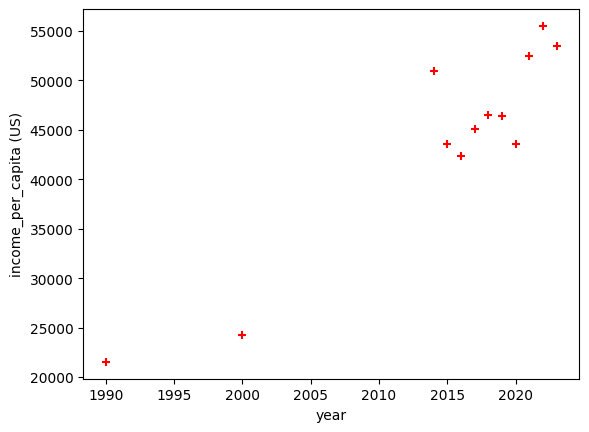

In [29]:
%matplotlib inline
plt.xlabel('year')
plt.ylabel('income_per_capita (US)')
plt.scatter(df.year, df.income_per_year, color='red',marker='+')
plt.show()

In [20]:
X = df[['year']]
y = df['income_per_year']

In [21]:
linear_reg = linear_model.LinearRegression()

In [22]:
linear_reg.fit(X, y)

LinearRegression()

In [23]:
linear_reg.predict([[2023]])

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([52375.58613043])

In [24]:
linear_reg.coef_

array([1018.25876829])

In [25]:
linear_reg.intercept_

np.float64(-2007561.9021176542)

In [26]:
year = pd.read_csv('year_2.csv')

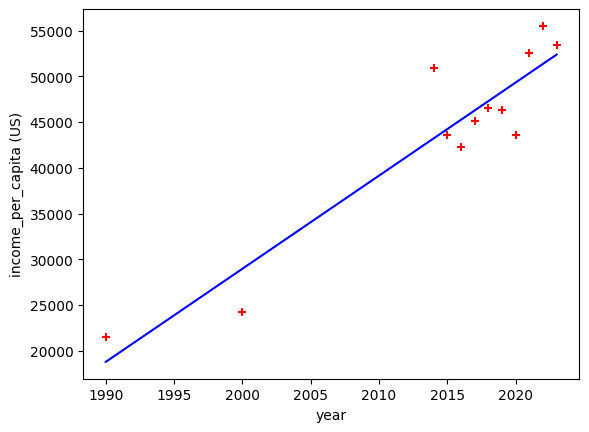

In [31]:
%matplotlib inline
plt.xlabel('year')
plt.ylabel('income_per_capita (US)')
plt.scatter(df.year, df.income_per_year, color='red',marker='+')
plt.plot(df.year, linear_reg.predict(df[['year']]), color='blue')
plt.show()

In [32]:
income_pred = linear_reg.predict(year)
year['income_per_capita_years'] = income_pred
year

,year,income_per_capita_years
0,1990,18773.046777
1,2000,28955.634460
2,2010,39138.222143
3,2011,40156.480911
4,2012,41174.739679
5,2013,42192.998448
6,2014,43211.257216
7,2015,44229.515984
8,2016,45247.774752
9,2017,46266.033521


In [34]:
from sklearn.model_selection import train_test_split

In [42]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state=42)

In [44]:
lr = linear_model.LinearRegression()

In [45]:
lr.fit(X_train, y_train)

LinearRegression()

In [46]:
predicted = lr.predict(X_test)

In [50]:
data = pd.DataFrame({'actual': y_test, 'predicted': predicted})

In [51]:
data

,actual,predicted
10,55509.393176,50970.799748
9,52496.844169,49852.828351
0,21525.861139,15195.715033


In [18]:
# c = pd.DataFrame({'country_name': ['Canada', 'Canada', 'Canada', 'Canada', 'Canada', 'Canada', 'Canada',
#                                  'Canada', 'Canada', 'Canada', 'Canada', 'Canada'],
#                 'year': [1990, 2000, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023], 
#                 'income_per_year': [21525.861139, 24271.002056, 50960.843117, 43594.194105, 42314.061582,
#                                     45129.628117, 46539.176157, 46352.869345, 43537.839299, 52496.844169, 
#                                     55509.393176, 53431.185706]})

In [17]:
# c.to_csv('canada_per_capita_income_2023.csv', index=False)